In [1]:
# Imports
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy
from numpy.typing import NDArray

In [2]:
# Paths
example_data_path = Path().resolve().parent.parent / "datasets" / "LineScan2D_WireTargets.mat"

In [3]:
# Parameters
f_low = 0.4e6  # Lower cutoff freq., transducer band
f_high = 2.5e6  # Upper cutoff freq., transducer band

In [4]:
# Load data
example_data = scipy.io.loadmat(example_data_path)
ptx = example_data["ptx"]  # 2D ultrasound data p(t,x)
fs = example_data["fs"].item()  # Sampling frequency
xstep = example_data["xStep"].item()  # Spatial step size (x-axis)
sound_vel = example_data["cc"].item()  # Sound velocity
t_delay = example_data["tDelay"].item()  # Pulse recording delay

nt, nx = ptx.shape


In [5]:
# Define helper functions


def nextpow2(n):
    """Round up number to next power of 2"""
    return int(2 ** ceil(np.log2(n)))


def get_envelope(im):
    return np.abs(scipy.signal.hilbert(im))  # type: ignore


def log_image(im):
    """Normalize image and transform to deciBel (log) scale"""
    return 20 * np.log10(im / np.max(im))


def plot_us_image(
    im: NDArray,
    x_ax_val: NDArray,
    y_ax_val: NDArray,
    x_ax_label: str = "",
    y_ax_label: str = "",
    title: str = "",
    min_db: float = -60,
    max_db: float = 0,
    figsize: tuple[float, float] = (6, 4),
):
    """Plot ultrasound image on logarithmic scale with colorbar"""
    _, ax = plt.subplots(figsize=figsize)
    im_handle = ax.imshow(
        log_image(np.abs(im)),
        interpolation="none",
        extent=(
            x_ax_val[0],
            x_ax_val[-1],
            y_ax_val[-1],
            y_ax_val[0],
        ),
        aspect="auto",
        vmin=min_db,
        vmax=max_db,
    )
    ax.set_xlabel(x_ax_label)
    ax.set_ylabel(y_ax_label)
    ax.set_title(title)

    cbar = plt.colorbar(im_handle)
    cbar.ax.set_ylabel("dB", rotation=270, labelpad=15)
    plt.show()


def get_kz_matrix(OMEGA, KX, sound_vel):
    """Calculate wavenumber kz for every combination of omega and kx"""
    KZ2 = ((2 / sound_vel) ** 2) * (OMEGA**2) - KX**2
    real_wave_index = KZ2 >= 0
    KZ = np.sqrt(KZ2 * real_wave_index)
    return KZ, real_wave_index


def get_phase_shift_matrix(KZ, dz):
    """Calculate incremental phase shift in z direction"""
    return np.exp(1j * KZ * dz)


def time_shift_to_zero(Pokx, t_delay, OMEGA):
    return Pokx * np.exp(-1j * OMEGA * t_delay)


def z_shift_to_measurement_start(Pokx, KZ, t_delay, sound_vel):
    z_start = t_delay * (sound_vel / 2)
    return Pokx * np.exp(1j * KZ * z_start)

In [6]:
# Static variables related to Z axis
z_start = t_delay * (sound_vel / 2)
z_end = z_start + (nt / fs) * (sound_vel / 2)
dz = (sound_vel / 2) / (f_high - f_low)  # Z resolution
nz = ceil((z_end - z_start) / dz)  # Number of z lines in focused im.

# Make time/space coodinate variables
nn = np.arange(nt)
tt = t_delay + nn / fs
xx = np.arange(nx) * xstep
zz = z_start + np.arange(nz) * dz

#  Make spectrum coordinate vectors
nfft_t = nextpow2(nt)
nfft_x = nextpow2(nx)
omega = np.fft.fftshift(np.fft.fftfreq(nfft_t, 1 / fs)) * (2 * np.pi)
# omega_band_ind = (omega <= -2 * np.pi * f_low) & (omega >= -2 * np.pi * f_high)
omega_band_ind = (omega >= 2 * np.pi * f_low) & (omega <= 2 * np.pi * f_high)
kx = np.fft.fftshift(np.fft.fftfreq(nfft_x, xstep)) * (2 * np.pi)

# Create meshgrid coordinate matrices
OMEGA, KX = np.meshgrid(omega, kx, indexing="ij")


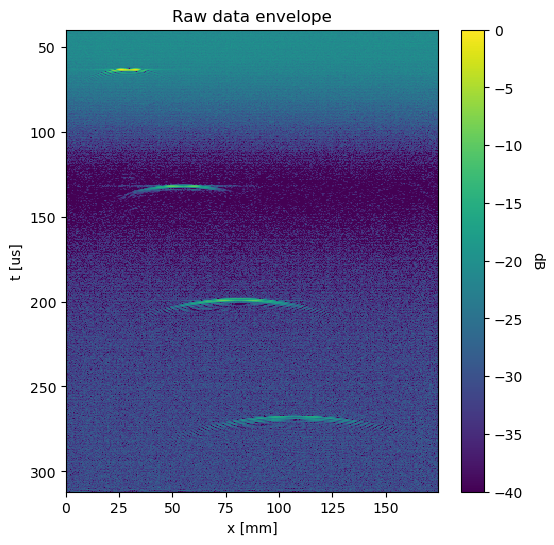

In [7]:
# Plot raw data
plot_us_image(
    get_envelope(ptx),
    x_ax_val=xx * 1e3,
    y_ax_val=tt * 1e6,
    x_ax_label="x [mm]",
    y_ax_label="t [us]",
    title="Raw data envelope",
    min_db=-40,
    figsize=(6, 6),
)


In [8]:
# 2D Fourier transform
Pokx = np.fft.fftshift(np.fft.fftn(ptx, s=(nfft_t, nfft_x)))

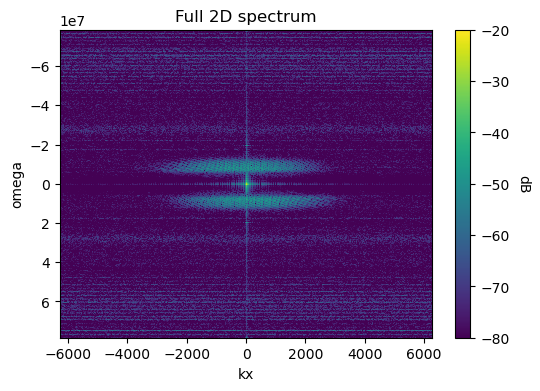

In [9]:
# Plot
plot_us_image(
    Pokx,
    x_ax_val=kx,
    y_ax_val=omega,
    x_ax_label="kx",
    y_ax_label="omega",
    title="Full 2D spectrum",
    min_db=-80,
    max_db=-20,
)

In [10]:
# %% Cut out part of spectrum corresponding to transducer freq. band, neg. omega
Pokx_band = Pokx[omega_band_ind, :]

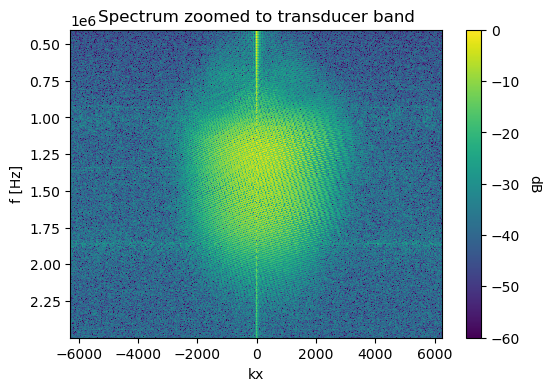

In [11]:
# Plot
plot_us_image(
    Pokx_band,
    x_ax_val=kx,
    y_ax_val=omega[omega_band_ind] / (2 * np.pi),
    x_ax_label="kx",
    y_ax_label="f [Hz]",
    title="Spectrum zoomed to transducer band",
)


In [12]:
# Calculate KZ
KZ, real_wave_index = get_kz_matrix(OMEGA[omega_band_ind], KX[omega_band_ind], sound_vel)


In [13]:
# Time shift to t=0
Pokx_t0 = time_shift_to_zero(Pokx_band, t_delay, OMEGA[omega_band_ind])
ptx_t0 = np.fft.ifftn(np.fft.ifftshift(Pokx_t0, axes=(1,)))
ptx_t0 = ptx_t0[0:nt, 0:nx]

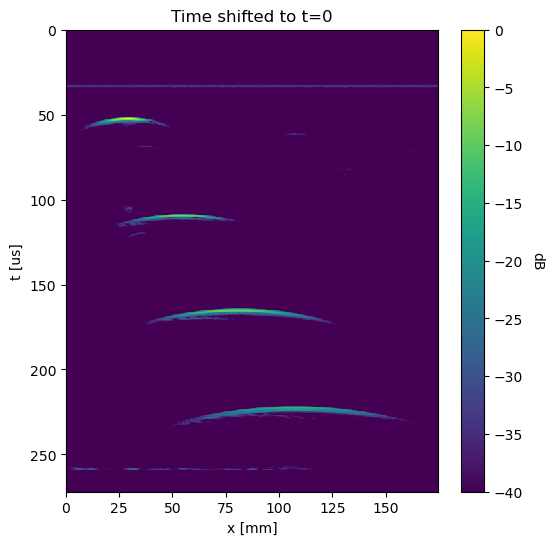

In [14]:
# Plot wavefield time shifted to t=0
plot_us_image(
    ptx_t0,
    x_ax_val=xx * 1e3,
    y_ax_val=(tt - t_delay) * 1e6,
    x_ax_label="x [mm]",
    y_ax_label="t [us]",
    title="Time shifted to t=0",
    min_db=-40,
    figsize=(6, 6),
)

# Interpolating from $(k_x,k_z)$ to $\omega$ 


In [22]:
nfft_z = nextpow2(nt * (f_high - f_low) / (fs / 2))
kzs = (2 * np.pi) / dz
kz = (2 * np.pi * f_low) / (sound_vel / 2) + np.arange(nfft_z) * (kzs / nfft_z)


Interpolation, see
https://docs.scipy.org/doc/scipy/tutorial/interpolate/1D.html#tutorial-interpolate-1dsection

PCHIP and cubic interpolators are probably the best options (other than straight linear
interpolation).

For support for complex numbers, the
"[RegularGridInterpolator](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.RegularGridInterpolator.html)"
is maybe the best option?

2048

In [ ]:
# ;                                        % Sampling kz
# kz = (2*pi*fLow)/(cc/2) + (0:(nFFTz-1))*(kzs/nFFTz);    % kz vector
# kz = -kz(end:-1:1);                     % Correspond to neg. omega
#
# %% Calculate new spectrum coordinates
# [KZ_st,KX_st] = ndgrid(kz,kx);
# KK2_st = (KZ_st.^2 + KX_st.^2);                     % KK^2
# KK_st = -sqrt(KK2_st .* (KK2_st > 0));              % KK, correspond to neg. om.

# Akzkx = 1./(1 + (KX_st.^2)./KZ_st.^2);              % Scale factor
# Akzkx(isnan(Akzkx)) = 1;

# OMEGA_st = (cc/2)*KK_st;                % New omega coord. for interplation

# %% Focus through spectrum resampling (this is where the magic happens)
# Pkzkx = complex(zeros(nFFTz,nFFTx));
# for jj = 1:nFFTx
#      Pkzkx(:,jj) = interp1(omegaBand,Pokx(:,jj),OMEGA_st(:,jj));
# end